# Домашняя работа: Seq2Seq with Attention

Задача: обучить word-level Seq2Seq with Attention для перевода English -> Russian на данных ManyThings / Tatoeba.

В качестве базы используется официальный tutorial PyTorch: https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html

Сохраняется учебная архитектура tutorial: `Lang`, `EncoderRNN`, `GRU`, `DataLoader`, teacher forcing, общий attention decoder и визуализация attention. В работе сравниваются два механизма внимания: dot product attention и MLP / Bahdanau attention.

## Импорты и настройки

`FAST_MODE = True` можно включить только для быстрой проверки кода. Финальная конфигурация ниже рассчитана на полноценный эксперимент.

In [1]:
%matplotlib inline

import math
import random
import re
import time
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

from IPython.display import display, Markdown

SEED = 42
FAST_MODE = False

MAX_LENGTH = 12
MAX_PAIRS = 30000
BATCH_SIZE = 64
HIDDEN_SIZE = 256
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
DROPOUT = 0.1
TEACHER_FORCING_RATIO = 0.5
CLIP_NORM = 1.0
EVAL_EXAMPLES = 12
ATTENTION_PLOTS = 3
BLEU_EVAL_LIMIT = None

if FAST_MODE:
    MAX_PAIRS = 3000
    BATCH_SIZE = 64
    HIDDEN_SIZE = 128
    NUM_EPOCHS = 2
    BLEU_EVAL_LIMIT = 500


def get_working_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")

    try:
        major, minor = torch.cuda.get_device_capability(0)
        current_arch = f"sm_{major}{minor}"
        supported_arches = torch.cuda.get_arch_list()

        if supported_arches and current_arch not in supported_arches:
            print(
                f"CUDA GPU найден ({torch.cuda.get_device_name(0)}, {current_arch}), "
                f"но текущий PyTorch поддерживает только {supported_arches}. Используем CPU."
            )
            return torch.device("cpu")

        test_tensor = torch.zeros(1, device="cuda")
        del test_tensor
        return torch.device("cuda")
    except Exception as error:
        print(f"CUDA недоступна для этой сборки PyTorch. Используем CPU. Причина: {error}")
        return torch.device("cpu")


device = get_working_device()


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print("Device:", device)
print(
    f"MAX_LENGTH={MAX_LENGTH}, MAX_PAIRS={MAX_PAIRS}, "
    f"BATCH_SIZE={BATCH_SIZE}, HIDDEN_SIZE={HIDDEN_SIZE}, NUM_EPOCHS={NUM_EPOCHS}"
)

Device: cuda
MAX_LENGTH=12, MAX_PAIRS=30000, BATCH_SIZE=64, HIDDEN_SIZE=256, NUM_EPOCHS=10


## Загрузка Russian-English ManyThings

Архив скачивается автоматически. В некоторых средах ManyThings возвращает HTTP 406 на стандартный `urllib`, поэтому запрос отправляется с обычным браузерным `User-Agent`.

In [2]:
DATA_URL = "https://www.manythings.org/anki/rus-eng.zip"
DATA_DIR = Path("data_manythings_attention")
ARCHIVE_PATH = DATA_DIR / "rus-eng.zip"

DATA_DIR.mkdir(parents=True, exist_ok=True)


def download_with_user_agent(url, destination):
    headers = {
        "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/124 Safari/537.36",
        "Accept": "application/zip, application/octet-stream, */*",
        "Accept-Language": "en-US,en;q=0.9",
    }
    request = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(request, timeout=60) as response:
        destination.write_bytes(response.read())


def is_valid_zip(path):
    if not path.exists():
        return False
    try:
        with zipfile.ZipFile(path, "r") as archive:
            return archive.testzip() is None
    except zipfile.BadZipFile:
        return False


if not is_valid_zip(ARCHIVE_PATH):
    if ARCHIVE_PATH.exists():
        ARCHIVE_PATH.unlink()
    print("Downloading", DATA_URL)
    download_with_user_agent(DATA_URL, ARCHIVE_PATH)
else:
    print("Archive already exists:", ARCHIVE_PATH)

with zipfile.ZipFile(ARCHIVE_PATH, "r") as archive:
    txt_names = [name for name in archive.namelist() if name.lower().endswith(".txt")]
    print("TXT files in archive:", txt_names)
    archive.extractall(DATA_DIR)

txt_files = sorted(DATA_DIR.rglob("*.txt"))
preferred = [path for path in txt_files if path.name.lower() == "rus.txt"]
DATA_TXT_PATH = preferred[0] if preferred else txt_files[0]

raw_lines = DATA_TXT_PATH.read_text(encoding="utf-8").splitlines()
print("Dataset txt path:", DATA_TXT_PATH)
print("Количество исходных пар:", len(raw_lines))

TXT files in archive: ['rus.txt', '_about.txt']
Dataset txt path: data_manythings_attention/rus.txt
Количество исходных пар: 536124


## Проверка формата ManyThings

В строке три tab-separated поля: English, Russian и metadata / attribution. Для обучения берутся только первые две колонки.

In [3]:
for line in raw_lines[:5]:
    parts = line.split("\t")
    print("-" * 80)
    print("Колонок:", len(parts))
    print("EN:", parts[0] if len(parts) > 0 else "")
    print("RU:", parts[1] if len(parts) > 1 else "")
    print("metadata:", parts[2][:90] if len(parts) > 2 else "")

--------------------------------------------------------------------------------
Колонок: 3
EN: Go.
RU: Марш!
metadata: CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #1159202 (shanghainese)
--------------------------------------------------------------------------------
Колонок: 3
EN: Go.
RU: Иди.
metadata: CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #5898247 (marafon)
--------------------------------------------------------------------------------
Колонок: 3
EN: Go.
RU: Идите.
metadata: CC-BY 2.0 (France) Attribution: tatoeba.org #2877272 (CM) & #5898250 (marafon)
--------------------------------------------------------------------------------
Колонок: 3
EN: Hi.
RU: Здравствуйте.
metadata: CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #402127 (odexed)
--------------------------------------------------------------------------------
Колонок: 3
EN: Hi.
RU: Привет!
metadata: CC-BY 2.0 (France) Attribution: tatoeba.org #538123 (CM) & #466968 (katj

## Preprocessing English и Russian

Оригинальная нормализация из French-English tutorial удаляет всё, кроме `a-zA-Z`, поэтому для русского языка она не подходит. Здесь английский и русский текст нормализуются разными функциями, а кириллица и буква `ё` сохраняются.

In [4]:
def normalize_english(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?])", r" \1 ", text)
    text = re.sub(r"[^a-z.!?]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_russian(text):
    text = text.lower().strip()
    text = re.sub(r"([.!?])", r" \1 ", text)
    text = re.sub(r"[^а-яё.!?]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


for en, ru in [
    ("I am tired.", "Я устал."),
    ("I love machine learning.", "Я люблю машинное обучение."),
    ("Do you understand me?", "Ты меня понимаешь?"),
]:
    print("EN:", normalize_english(en))
    print("RU:", normalize_russian(ru))
    print()

EN: i am tired .
RU: я устал .

EN: i love machine learning .
RU: я люблю машинное обучение .

EN: do you understand me ?
RU: ты меня понимаешь ?



## Train / validation / test split

Направление перевода: English -> Russian. Фильтр `eng_prefixes` из French-English tutorial не используется. Один и тот же split применяется для обоих attention-механизмов.

In [5]:
def read_manythings_pairs(path):
    pairs = []
    skipped = 0

    for line in path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split("\t")
        if len(parts) < 2:
            skipped += 1
            continue

        english = normalize_english(parts[0])
        russian = normalize_russian(parts[1])

        if not english or not russian:
            skipped += 1
            continue

        if len(english.split()) <= MAX_LENGTH and len(russian.split()) <= MAX_LENGTH:
            pairs.append([english, russian])

    return pairs, skipped


all_pairs, skipped_lines = read_manythings_pairs(DATA_TXT_PATH)
print("Пропущено строк:", skipped_lines)
print("Пар после preprocessing и фильтрации длины:", len(all_pairs))

split_rng = random.Random(SEED)
split_rng.shuffle(all_pairs)
pairs = all_pairs[:MAX_PAIRS]

train_end = int(0.8 * len(pairs))
val_end = int(0.9 * len(pairs))

train_pairs = pairs[:train_end]
val_pairs = pairs[train_end:val_end]
test_pairs = pairs[val_end:]

print("Используется пар:", len(pairs))
print("Train:", len(train_pairs))
print("Validation:", len(val_pairs))
print("Test:", len(test_pairs))

print("\nПроверка сохранения кириллицы:")
for en, ru in train_pairs[:8]:
    print("EN:", en)
    print("RU:", ru)
    print()

Пропущено строк: 0
Пар после preprocessing и фильтрации длины: 519092
Используется пар: 30000
Train: 24000
Validation: 3000
Test: 3000

Проверка сохранения кириллицы:
EN: tom went inside the house .
RU: том вошёл в дом .

EN: we want a better life .
RU: мы хотим лучшей жизни .

EN: tom is available .
RU: том доступен .

EN: i despised you .
RU: я презирал тебя .

EN: everyone in my family enjoys watching tv .
RU: все в нашей семье любят смотреть телевизор .

EN: i think i ll buy a new car .
RU: я пожалуй куплю новую машину .

EN: tom didn t have to explain it to me .
RU: тому не понадобилось это мне объяснять .

EN: the fish we want to eat hasn t been caught yet .
RU: та рыба которую мы хотим съесть ещё не поймана .



## Vocabulary

Сохраняется подход tutorial с классом `Lang`, но добавляются `PAD` и `UNK`. Словари строятся только по train dataset, поэтому validation/test не участвуют в обучении словаря.

In [6]:
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

SPECIAL_TOKENS = {
    PAD_token: "PAD",
    SOS_token: "SOS",
    EOS_token: "EOS",
    UNK_token: "UNK",
}


class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {
            "PAD": PAD_token,
            "SOS": SOS_token,
            "EOS": EOS_token,
            "UNK": UNK_token,
        }
        self.word2count = {}
        self.index2word = dict(SPECIAL_TOKENS)
        self.n_words = 4

    def addSentence(self, sentence):
        for word in sentence.split(" "):
            self.addWord(word)

    def addWord(self, word):
        if not word:
            return
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        elif word not in {"PAD", "SOS", "EOS", "UNK"}:
            self.word2count[word] += 1


input_lang = Lang("English")
output_lang = Lang("Russian")

for english, russian in train_pairs:
    input_lang.addSentence(english)
    output_lang.addSentence(russian)

print("Counted words:")
print(input_lang.name, input_lang.n_words)
print(output_lang.name, output_lang.n_words)
print("UNK index for unknown word:", input_lang.word2index.get("__not_in_train__", UNK_token))


def indexesFromSentence(lang, sentence):
    return [lang.word2index.get(word, UNK_token) for word in sentence.split(" ") if word]


def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long)


def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return input_tensor, target_tensor

Counted words:
English 5811
Russian 13860
UNK index for unknown word: 3


## Dataset и DataLoader

`collate_fn` превращает пары предложений в индексы, добавляет `EOS` и делает padding до максимальной длины внутри batch. Маска encoder строится как `input_tensor != PAD_token`.

In [7]:
class TranslationDataset(Dataset):
    def __init__(self, sentence_pairs):
        self.sentence_pairs = sentence_pairs

    def __len__(self):
        return len(self.sentence_pairs)

    def __getitem__(self, idx):
        return self.sentence_pairs[idx]


def make_collate_fn(input_lang, output_lang):
    def collate_fn(batch):
        input_tensors = [tensorFromSentence(input_lang, en) for en, _ in batch]
        target_tensors = [tensorFromSentence(output_lang, ru) for _, ru in batch]

        input_tensor = pad_sequence(
            input_tensors,
            batch_first=True,
            padding_value=PAD_token,
        )
        target_tensor = pad_sequence(
            target_tensors,
            batch_first=True,
            padding_value=PAD_token,
        )
        return input_tensor, target_tensor

    return collate_fn


collate_fn = make_collate_fn(input_lang, output_lang)


def make_loaders(seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        TranslationDataset(train_pairs),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
        generator=generator,
    )
    val_loader = DataLoader(
        TranslationDataset(val_pairs),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )
    test_loader = DataLoader(
        TranslationDataset(test_pairs),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )
    return train_loader, val_loader, test_loader


def get_batch_with_padding(data_loader):
    first_batch = None
    for batch in data_loader:
        if first_batch is None:
            first_batch = batch
        batch_input, batch_target = batch
        if (batch_input == PAD_token).any() or (batch_target == PAD_token).any():
            return batch
    return first_batch


train_loader, val_loader, test_loader = make_loaders(SEED)
input_batch, target_batch = get_batch_with_padding(train_loader)
encoder_mask_batch = input_batch != PAD_token

print("input_tensor shape:", tuple(input_batch.shape))
print("target_tensor shape:", tuple(target_batch.shape))
print("encoder mask shape:", tuple(encoder_mask_batch.shape))
print("PAD positions in sample batch:", int((~encoder_mask_batch).sum().item()))

input_tensor shape: (64, 12)
target_tensor shape: (64, 13)
encoder mask shape: (64, 12)
PAD positions in sample batch: 244


## Теория Seq2Seq и Attention

Обычный Seq2Seq пытается сжать всё исходное предложение в одно hidden state. Attention позволяет decoder на каждом шаге посмотреть на все `encoder_outputs` и выбрать, какие исходные слова сейчас важнее.

Например, при переводе `I love machine learning`, когда decoder генерирует слово `машинное`, attention может дать больший вес слову `machine`.

```text
encoder outputs
 h1  h2  h3  h4
  \   |  /   /
   attention
       |
context vector
       |
decoder
```

Dot Product Attention считает совместимость как `score(q, k) = q * k`. MLP / Bahdanau Attention использует обучаемую функцию `v^T tanh(Wq q + Wk k)`. Фактический вывод о качестве делается только после экспериментов.

## Encoder

Encoder близок к PyTorch tutorial: `Embedding -> Dropout -> GRU`, `batch_first=True`. Он возвращает все output-векторы для attention и последнее hidden state для decoder.

In [8]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

    def forward(self, input_tensor):
        embedded = self.dropout(self.embedding(input_tensor))
        encoder_outputs, encoder_hidden = self.gru(embedded)
        return encoder_outputs, encoder_hidden

## Dot Product Attention

В первом эксперименте attention score считается именно скалярным произведением query decoder и encoder keys. Перед `softmax` PAD-позиции маскируются.

In [9]:
class DotProductAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

    def forward(self, query, keys, mask):
        scores = torch.bmm(query, keys.transpose(1, 2))
        scores = scores.masked_fill(~mask.unsqueeze(1), -1e9)
        attention_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attention_weights, keys)
        return context, attention_weights

## MLP / Bahdanau Attention

Во втором эксперименте score вычисляется обучаемой MLP-функцией совместимости `v^T tanh(Wq q + Wk k)`. Интерфейс совпадает с dot product attention.

In [10]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys, mask):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.transpose(1, 2)
        scores = scores.masked_fill(~mask.unsqueeze(1), -1e9)
        attention_weights = F.softmax(scores, dim=-1)
        context = torch.bmm(attention_weights, keys)
        return context, attention_weights

## Универсальный AttnDecoderRNN

Decoder общий для двух экспериментов. Меняется только attention module, который передаётся в конструктор.

In [11]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, attention, dropout_p=0.1):
        super().__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.attention = attention
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward_step(self, input_tokens, hidden, encoder_outputs, encoder_mask):
        embedded = self.dropout(self.embedding(input_tokens)).unsqueeze(1)
        query = hidden.permute(1, 0, 2)
        context, attention_weights = self.attention(query, encoder_outputs, encoder_mask)
        rnn_input = torch.cat((embedded, context), dim=-1)
        output, hidden = self.gru(rnn_input, hidden)
        logits = self.out(output.squeeze(1))
        return logits, hidden, attention_weights

    def forward(
        self,
        encoder_outputs,
        encoder_hidden,
        encoder_mask,
        target_tensor=None,
        max_length=None,
        teacher_forcing_ratio=0.0,
    ):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.full(
            (batch_size,),
            SOS_token,
            dtype=torch.long,
            device=encoder_outputs.device,
        )
        decoder_hidden = encoder_hidden

        if target_tensor is not None:
            decode_length = target_tensor.size(1)
        else:
            decode_length = max_length or MAX_LENGTH

        logits_by_step = []
        attention_by_step = []

        for timestep in range(decode_length):
            logits, decoder_hidden, attention_weights = self.forward_step(
                decoder_input,
                decoder_hidden,
                encoder_outputs,
                encoder_mask,
            )
            logits_by_step.append(logits.unsqueeze(1))
            attention_by_step.append(attention_weights)

            predicted_tokens = logits.argmax(dim=1).detach()
            use_teacher_forcing = (
                target_tensor is not None
                and random.random() < teacher_forcing_ratio
            )
            decoder_input = target_tensor[:, timestep] if use_teacher_forcing else predicted_tokens

        logits = torch.cat(logits_by_step, dim=1)
        attention_weights = torch.cat(attention_by_step, dim=1)
        return logits, decoder_hidden, attention_weights

## Проверка размерностей и attention mask

Проверяем формы tensors до полноценного обучения. Также проверяем, что сумма attention weights по source length равна 1, а PAD-позиции получают почти нулевой вес, потому что перед `softmax` они замаскированы большим отрицательным числом.

In [12]:
def check_shapes_and_attention(attention_module, attention_name):
    sample_input = input_batch.to(device)
    sample_target = target_batch.to(device)
    sample_mask = sample_input != PAD_token

    encoder = EncoderRNN(input_lang.n_words, HIDDEN_SIZE, DROPOUT).to(device)
    decoder = AttnDecoderRNN(
        HIDDEN_SIZE,
        output_lang.n_words,
        attention=attention_module.to(device),
        dropout_p=DROPOUT,
    ).to(device)

    encoder_outputs, encoder_hidden = encoder(sample_input)
    query = encoder_hidden.permute(1, 0, 2)
    context, attention_weights = decoder.attention(query, encoder_outputs, sample_mask)
    logits, _, all_attention = decoder(
        encoder_outputs,
        encoder_hidden,
        sample_mask,
        target_tensor=sample_target,
        teacher_forcing_ratio=0.0,
    )

    print(attention_name)
    print("Input:", tuple(sample_input.shape))
    print("Encoder outputs:", tuple(encoder_outputs.shape))
    print("Encoder hidden:", tuple(encoder_hidden.shape))
    print("Attention scores/weights:", tuple(attention_weights.shape))
    print("Context:", tuple(context.shape))
    print("Decoder logits:", tuple(logits.shape))
    print("All decoder attention:", tuple(all_attention.shape))

    sums = all_attention.sum(dim=-1)
    print("attention_weights.sum(dim=-1), first 3 rows:")
    print(sums[:3].detach().cpu())
    print("max abs(sum - 1):", float((sums - 1.0).abs().max().item()))

    pad_weights = all_attention.masked_select(~sample_mask.unsqueeze(1))
    if pad_weights.numel() > 0:
        print("max PAD attention weight:", float(pad_weights.max().item()))
    else:
        print("В этом batch нет PAD-позиций.")


check_shapes_and_attention(DotProductAttention(HIDDEN_SIZE), "Dot Product Attention")

Dot Product Attention
Input: (64, 12)
Encoder outputs: (64, 12, 256)
Encoder hidden: (1, 64, 256)
Attention scores/weights: (64, 1, 12)
Context: (64, 1, 256)
Decoder logits: (64, 13, 13860)
All decoder attention: (64, 13, 12)
attention_weights.sum(dim=-1), first 3 rows:
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000]])
max abs(sum - 1): 1.7881393432617188e-07
max PAD attention weight: 0.0


## Train / validation функции

Loss считается через `CrossEntropyLoss(ignore_index=PAD_token)`, поэтому PAD-токены не влияют на оптимизацию. Validation loss считается авторегрессионно: target нужен только для длины decoding и расчёта loss, но не подаётся как подсказка.

In [13]:
def asMinutes(seconds):
    minutes = math.floor(seconds / 60)
    seconds -= minutes * 60
    return f"{minutes}m {int(seconds)}s"


def count_non_pad_tokens(target_tensor):
    return int((target_tensor != PAD_token).sum().item())


def train_batch(
    input_tensor,
    target_tensor,
    encoder,
    decoder,
    encoder_optimizer,
    decoder_optimizer,
    criterion,
):
    encoder.train()
    decoder.train()

    input_tensor = input_tensor.to(device)
    target_tensor = target_tensor.to(device)
    encoder_mask = input_tensor != PAD_token

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    encoder_outputs, encoder_hidden = encoder(input_tensor)
    logits, _, attention_weights = decoder(
        encoder_outputs,
        encoder_hidden,
        encoder_mask,
        target_tensor=target_tensor,
        teacher_forcing_ratio=TEACHER_FORCING_RATIO,
    )

    loss = criterion(
        logits.reshape(-1, logits.size(-1)),
        target_tensor.reshape(-1),
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), CLIP_NORM)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), CLIP_NORM)
    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item(), count_non_pad_tokens(target_tensor)


def evaluate_loss(data_loader, encoder, decoder, criterion):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for input_tensor, target_tensor in data_loader:
            input_tensor = input_tensor.to(device)
            target_tensor = target_tensor.to(device)
            encoder_mask = input_tensor != PAD_token

            encoder_outputs, encoder_hidden = encoder(input_tensor)
            logits, _, attention_weights = decoder(
                encoder_outputs,
                encoder_hidden,
                encoder_mask,
                target_tensor=target_tensor,
                teacher_forcing_ratio=0.0,
            )
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_tensor.reshape(-1),
            )
            tokens = count_non_pad_tokens(target_tensor)
            total_loss += loss.item() * tokens
            total_tokens += tokens

    return total_loss / max(total_tokens, 1)


def train_model(encoder, decoder, train_loader, val_loader, num_epochs=NUM_EPOCHS):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=LEARNING_RATE)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=LEARNING_RATE)
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()
        train_loss_total = 0.0
        train_tokens = 0

        for input_tensor, target_tensor in train_loader:
            batch_loss, tokens = train_batch(
                input_tensor,
                target_tensor,
                encoder,
                decoder,
                encoder_optimizer,
                decoder_optimizer,
                criterion,
            )
            train_loss_total += batch_loss * tokens
            train_tokens += tokens

        train_loss = train_loss_total / max(train_tokens, 1)
        val_loss = evaluate_loss(val_loader, encoder, decoder, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"time: {asMinutes(time.time() - epoch_start)}"
        )

    return history

## Функция перевода

Inference выполняется без teacher forcing: decoder начинает с `SOS`, затем каждый следующий вход берётся из собственного `argmax` prediction.

In [14]:
def translate(encoder, decoder, sentence, max_length=MAX_LENGTH):
    encoder.eval()
    decoder.eval()

    normalized_sentence = normalize_english(sentence)
    input_tensor = tensorFromSentence(input_lang, normalized_sentence).unsqueeze(0).to(device)
    encoder_mask = input_tensor != PAD_token

    decoded_words = []
    attention_rows = []

    with torch.no_grad():
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_input = torch.tensor([SOS_token], dtype=torch.long, device=device)
        decoder_hidden = encoder_hidden

        for _ in range(max_length):
            logits, decoder_hidden, attention_weights = decoder.forward_step(
                decoder_input,
                decoder_hidden,
                encoder_outputs,
                encoder_mask,
            )
            next_token = int(logits.argmax(dim=1).item())

            if next_token == EOS_token:
                break

            if next_token not in {PAD_token, SOS_token}:
                decoded_words.append(output_lang.index2word.get(next_token, "UNK"))
                attention_rows.append(attention_weights.squeeze(0).squeeze(0).detach().cpu().numpy())

            decoder_input = torch.tensor([next_token], dtype=torch.long, device=device)

    if attention_rows:
        attention_matrix = np.vstack(attention_rows)
    else:
        attention_matrix = np.zeros((0, input_tensor.size(1)))

    return " ".join(decoded_words), attention_matrix

## BLEU / chrF / Exact Match

Метрики считаются на test dataset. `SOS`, `EOS` и `PAD` в строки перевода не попадают.

In [15]:
def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def corpus_bleu(references, predictions, max_n=4, smooth=1.0):
    clipped_counts = [0] * max_n
    total_counts = [0] * max_n
    reference_length = 0
    prediction_length = 0

    for reference, prediction in zip(references, predictions):
        ref_tokens = reference.split()
        pred_tokens = prediction.split()
        reference_length += len(ref_tokens)
        prediction_length += len(pred_tokens)

        for n in range(1, max_n + 1):
            pred_ngrams = ngram_counts(pred_tokens, n)
            ref_ngrams = ngram_counts(ref_tokens, n)
            clipped_counts[n - 1] += sum(
                min(count, ref_ngrams[ngram])
                for ngram, count in pred_ngrams.items()
            )
            total_counts[n - 1] += max(len(pred_tokens) - n + 1, 0)

    if prediction_length == 0:
        return 0.0

    precisions = [
        (clipped_counts[i] + smooth) / (total_counts[i] + smooth)
        for i in range(max_n)
    ]
    log_precision = sum(math.log(p) for p in precisions) / max_n
    brevity_penalty = 1.0
    if prediction_length < reference_length:
        brevity_penalty = math.exp(1 - reference_length / max(prediction_length, 1))

    return 100.0 * brevity_penalty * math.exp(log_precision)


def char_ngrams(text, n):
    text = text.replace(" ", "")
    return Counter(text[i:i + n] for i in range(len(text) - n + 1))


def corpus_chrf(references, predictions, max_n=6, beta=2.0):
    beta2 = beta ** 2
    f_scores = []

    for n in range(1, max_n + 1):
        matches = 0
        pred_total = 0
        ref_total = 0

        for reference, prediction in zip(references, predictions):
            pred_counts = char_ngrams(prediction, n)
            ref_counts = char_ngrams(reference, n)

            pred_total += sum(pred_counts.values())
            ref_total += sum(ref_counts.values())
            matches += sum(
                min(count, ref_counts[ngram])
                for ngram, count in pred_counts.items()
            )

        precision = matches / pred_total if pred_total else 0.0
        recall = matches / ref_total if ref_total else 0.0
        if precision == 0.0 and recall == 0.0:
            f_scores.append(0.0)
        else:
            f_scores.append((1 + beta2) * precision * recall / (beta2 * precision + recall))

    return 100.0 * float(np.mean(f_scores))


def evaluate_translation_quality(encoder, decoder, sentence_pairs, limit=BLEU_EVAL_LIMIT):
    if limit is not None and len(sentence_pairs) > limit:
        eval_pairs = random.Random(SEED).sample(sentence_pairs, limit)
    else:
        eval_pairs = sentence_pairs

    references = []
    predictions = []

    for english, russian in eval_pairs:
        prediction, attention_matrix = translate(encoder, decoder, english)
        predictions.append(prediction)
        references.append(russian)

    return {
        "BLEU": corpus_bleu(references, predictions),
        "chrF": corpus_chrf(references, predictions),
        "Exact match": float(np.mean([pred == ref for pred, ref in zip(predictions, references)])),
        "Evaluated translations": len(eval_pairs),
    }

## Experiment 1 — Dot Product Attention

## Experiment 2 — MLP / Bahdanau Attention

Обе модели обучаются с одинаковыми гиперпараметрами. Меняется только attention mechanism.

In [16]:
EXPERIMENTS = [
    {
        "name": "Dot Product Attention",
        "attention": "Dot Product",
        "attention_factory": lambda: DotProductAttention(HIDDEN_SIZE),
    },
    {
        "name": "MLP / Bahdanau Attention",
        "attention": "MLP/Bahdanau",
        "attention_factory": lambda: BahdanauAttention(HIDDEN_SIZE),
    },
]


def count_parameters(encoder, decoder):
    return sum(
        p.numel()
        for p in list(encoder.parameters()) + list(decoder.parameters())
        if p.requires_grad
    )


def build_model_pair(attention_factory):
    set_seed(SEED)
    encoder = EncoderRNN(input_lang.n_words, HIDDEN_SIZE, DROPOUT).to(device)

    set_seed(SEED + 1)
    attention = attention_factory().to(device)

    set_seed(SEED + 2)
    decoder = AttnDecoderRNN(
        HIDDEN_SIZE,
        output_lang.n_words,
        attention=attention,
        dropout_p=DROPOUT,
    ).to(device)
    return encoder, decoder


def run_experiment(name, attention, attention_factory):
    print("=" * 90)
    print(name)

    set_seed(SEED)
    train_loader, val_loader, test_loader = make_loaders(SEED)
    encoder, decoder = build_model_pair(attention_factory)

    parameters = count_parameters(encoder, decoder)
    print("Parameters:", parameters)

    start = time.time()
    history = train_model(encoder, decoder, train_loader, val_loader, NUM_EPOCHS)
    train_time = time.time() - start

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)
    test_loss = evaluate_loss(test_loader, encoder, decoder, criterion)
    quality = evaluate_translation_quality(encoder, decoder, test_pairs)

    metrics = {
        "Model": "Seq2Seq",
        "Attention": attention,
        "Best val loss": min(history["val_loss"]),
        "Test loss": test_loss,
        "BLEU": quality["BLEU"],
        "chrF": quality["chrF"],
        "Exact match": quality["Exact match"],
        "Parameters": parameters,
        "Train time": train_time,
        "Evaluated translations": quality["Evaluated translations"],
    }

    print(
        f"Done: test loss={test_loss:.4f}, BLEU={metrics['BLEU']:.2f}, "
        f"chrF={metrics['chrF']:.2f}, exact={metrics['Exact match']:.4f}, "
        f"time={asMinutes(train_time)}"
    )

    return {
        "encoder": encoder,
        "decoder": decoder,
        "history": history,
        "metrics": metrics,
    }

In [17]:
experiments_output = {}

for config in EXPERIMENTS:
    output = run_experiment(**config)
    experiments_output[config["attention"]] = output

Dot Product Attention
Parameters: 9583908
Epoch 01/10 | train loss: 5.1359 | val loss: 4.8191 | time: 0m 10s
Epoch 02/10 | train loss: 4.1594 | val loss: 4.4004 | time: 0m 10s
Epoch 03/10 | train loss: 3.5937 | val loss: 4.1743 | time: 0m 10s
Epoch 04/10 | train loss: 3.1470 | val loss: 4.0667 | time: 0m 10s
Epoch 05/10 | train loss: 2.7667 | val loss: 3.9414 | time: 0m 9s
Epoch 06/10 | train loss: 2.4342 | val loss: 3.8924 | time: 0m 10s
Epoch 07/10 | train loss: 2.1400 | val loss: 3.8618 | time: 0m 10s
Epoch 08/10 | train loss: 1.8768 | val loss: 3.8476 | time: 0m 10s
Epoch 09/10 | train loss: 1.6430 | val loss: 3.8855 | time: 0m 10s
Epoch 10/10 | train loss: 1.4424 | val loss: 3.9047 | time: 0m 10s
Done: test loss=3.8154, BLEU=13.98, chrF=31.23, exact=0.0120, time=1m 44s
MLP / Bahdanau Attention
Parameters: 9715749
Epoch 01/10 | train loss: 5.0630 | val loss: 4.6737 | time: 0m 12s
Epoch 02/10 | train loss: 3.9439 | val loss: 4.1505 | time: 0m 12s
Epoch 03/10 | train loss: 3.3057 | v

## Графики обучения

Графики строятся по реально сохранённым `history` двух экспериментов.

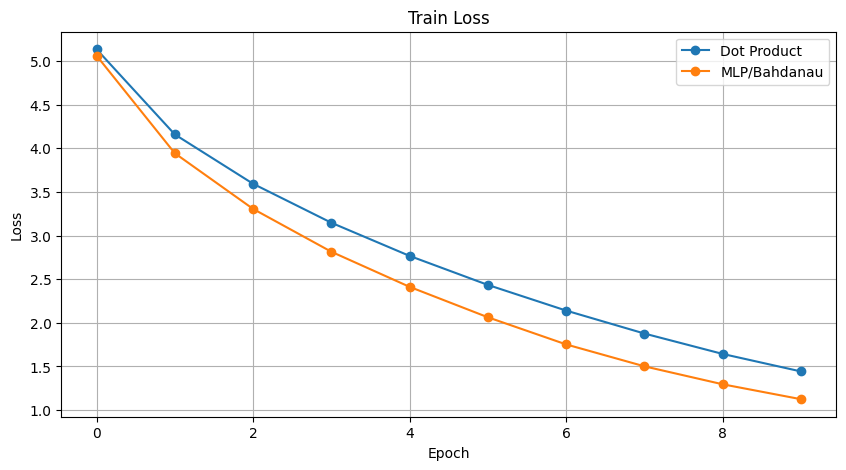

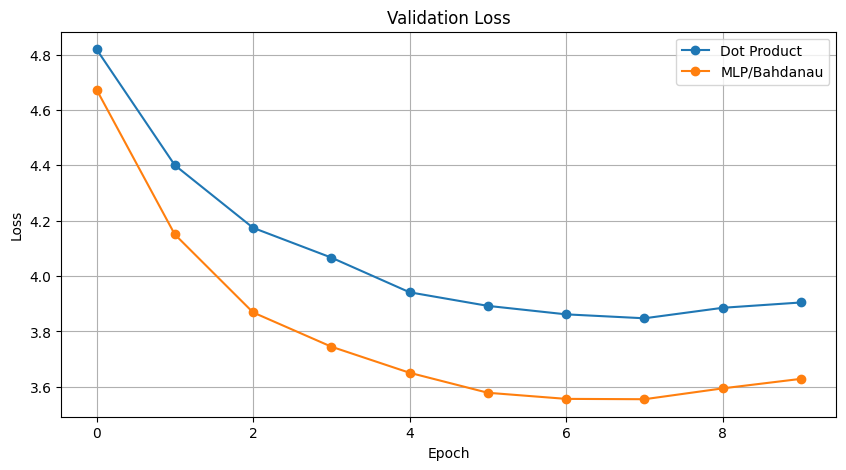

In [18]:
plt.figure(figsize=(10, 5))
for attention_name, output in experiments_output.items():
    plt.plot(output["history"]["train_loss"], marker="o", label=attention_name)
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for attention_name, output in experiments_output.items():
    plt.plot(output["history"]["val_loss"], marker="o", label=attention_name)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

## Сравнительная таблица

Все значения считаются программно после обучения и оценки на одном и том же test dataset.

In [19]:
results_df = pd.DataFrame(
    [output["metrics"] for output in experiments_output.values()]
)

ordered_columns = [
    "Model",
    "Attention",
    "Best val loss",
    "Test loss",
    "BLEU",
    "chrF",
    "Exact match",
    "Parameters",
    "Train time",
    "Evaluated translations",
]
results_df = results_df[ordered_columns]

display(
    results_df.style.format({
        "Best val loss": "{:.4f}",
        "Test loss": "{:.4f}",
        "BLEU": "{:.2f}",
        "chrF": "{:.2f}",
        "Exact match": "{:.4f}",
        "Parameters": "{:,}",
        "Train time": "{:.1f}",
    })
)

,Model,Attention,Best val loss,Test loss,BLEU,chrF,Exact match,Parameters,Train time,Evaluated translations
0,Seq2Seq,Dot Product,3.8476,3.8154,13.98,31.23,0.0120,"9,583,908",104.0,3000
1,Seq2Seq,MLP/Bahdanau,3.5554,3.5551,17.83,38.28,0.0207,"9,715,749",125.9,3000


## Примеры переводов

Для обеих моделей используются одни и те же test-предложения с фиксированным seed. Примеры не выбираются вручную.

In [20]:
example_rng = random.Random(SEED)
example_pairs = example_rng.sample(test_pairs, min(EVAL_EXAMPLES, len(test_pairs)))

for english, reference in example_pairs:
    print("=" * 90)
    print("English:")
    print(english)
    print("\nReference:")
    print(reference)

    for attention_name, output in experiments_output.items():
        prediction, attention_matrix = translate(output["encoder"], output["decoder"], english)
        print(f"\n{attention_name}:")
        print(prediction)

    print()

English:
i hope that that s not true .

Reference:
надеюсь это неправда .

Dot Product:
надеюсь это не неправда .

MLP/Bahdanau:
надеюсь это неправда .

English:
tom told me he had been sick .

Reference:
том сказал мне что был болен .

Dot Product:
том сказал мне что у него есть .

MLP/Bahdanau:
том сказал мне что у него клаустрофобия .

English:
i m going to tell tom what happened .

Reference:
я собираюсь рассказать тому что произошло .

Dot Product:
я скажу тому что том .

MLP/Bahdanau:
я собираюсь сказать тому что произошло .

English:
how did you do that ?

Reference:
как ты это сделал ?

Dot Product:
как ты это сделал ?

MLP/Bahdanau:
как ты это сделал ?

English:
tom didn t know who it was .

Reference:
том не знал кто это .

Dot Product:
том не знал кто это этом .

MLP/Bahdanau:
том не знал кто это был .

English:
you re a lost cause .

Reference:
ты неисправим .

Dot Product:
вы придурок .

MLP/Bahdanau:
вы гитарист .

English:
you have no idea .

Reference:
ты даже не предст

## Визуализация attention

Heatmap показывает реальные attention weights из greedy decoding. По X расположены английские input tokens, по Y — сгенерированные русские tokens.

English: i hope that that s not true .
Reference: надеюсь это неправда .
Dot Product: надеюсь это не неправда .


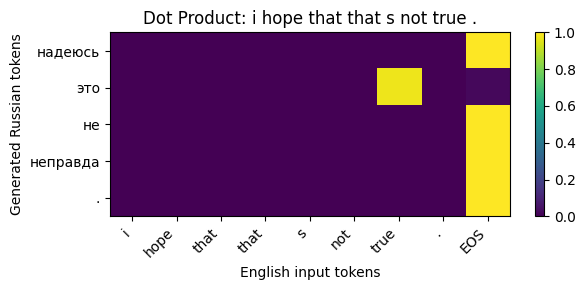

MLP/Bahdanau: надеюсь это неправда .


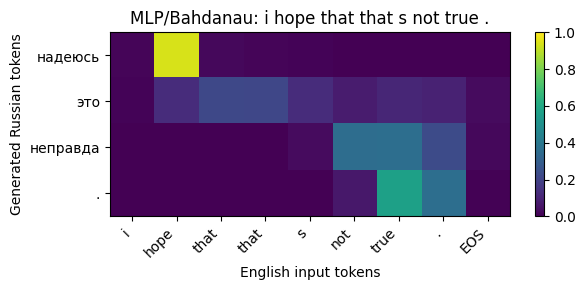

English: tom told me he had been sick .
Reference: том сказал мне что был болен .
Dot Product: том сказал мне что у него есть .


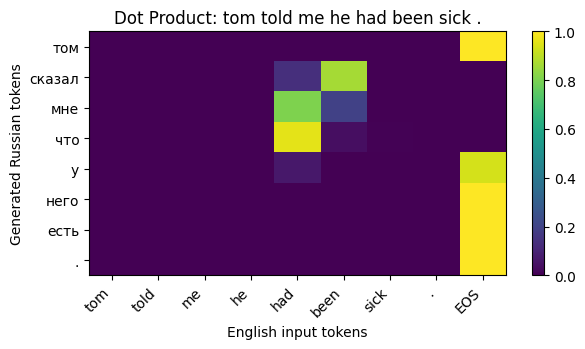

MLP/Bahdanau: том сказал мне что у него клаустрофобия .


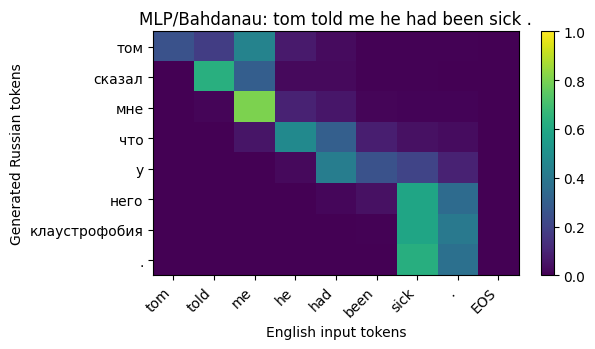

English: i m going to tell tom what happened .
Reference: я собираюсь рассказать тому что произошло .
Dot Product: я скажу тому что том .


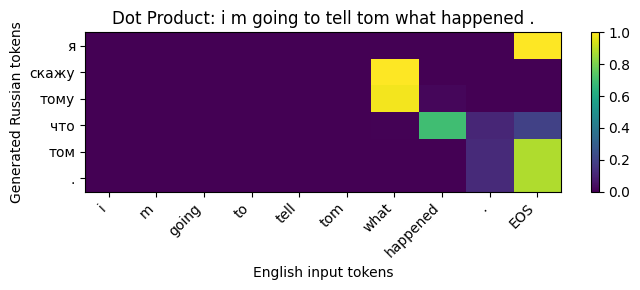

MLP/Bahdanau: я собираюсь сказать тому что произошло .


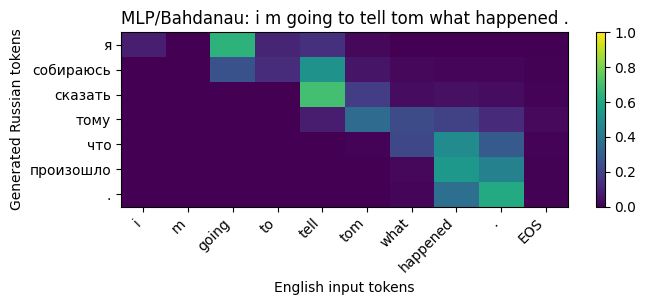

In [21]:
def plot_attention_heatmap(english, prediction, attention_matrix, title):
    input_tokens = normalize_english(english).split() + ["EOS"]
    output_tokens = prediction.split()

    if len(output_tokens) == 0:
        output_tokens = ["<empty>"]
        attention_matrix = np.zeros((1, len(input_tokens)))

    attention_matrix = attention_matrix[:len(output_tokens), :len(input_tokens)]

    fig, ax = plt.subplots(figsize=(max(6, len(input_tokens) * 0.7), max(3, len(output_tokens) * 0.45)))
    im = ax.imshow(attention_matrix, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_xticks(range(len(input_tokens)))
    ax.set_xticklabels(input_tokens, rotation=45, ha="right")
    ax.set_yticks(range(len(output_tokens)))
    ax.set_yticklabels(output_tokens)
    ax.set_xlabel("English input tokens")
    ax.set_ylabel("Generated Russian tokens")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


attention_examples = example_pairs[:min(ATTENTION_PLOTS, len(example_pairs))]

for english, reference in attention_examples:
    print("=" * 90)
    print("English:", english)
    print("Reference:", reference)

    for attention_name, output in experiments_output.items():
        prediction, attention_matrix = translate(output["encoder"], output["decoder"], english)
        print(f"{attention_name}:", prediction)
        plot_attention_heatmap(
            english,
            prediction,
            attention_matrix,
            f"{attention_name}: {english}",
        )

# Выводы

Следующая ячейка строит выводы только по фактически полученным результатам из таблицы.

In [22]:
def signed_delta(new, old):
    return new - old


def pct_delta(new, old):
    if old == 0:
        return float("nan")
    return 100.0 * (new - old) / old


df = results_df.copy()
dot = df[df["Attention"] == "Dot Product"].iloc[0]
mlp = df[df["Attention"] == "MLP/Bahdanau"].iloc[0]

best_bleu = df.loc[df["BLEU"].idxmax()]
best_chrf = df.loc[df["chrF"].idxmax()]
best_val = df.loc[df["Best val loss"].idxmin()]
best_test = df.loc[df["Test loss"].idxmin()]
fastest = df.loc[df["Train time"].idxmin()]

bleu_delta = signed_delta(mlp["BLEU"], dot["BLEU"])
chrf_delta = signed_delta(mlp["chrF"], dot["chrF"])
val_delta = signed_delta(mlp["Best val loss"], dot["Best val loss"])
test_delta = signed_delta(mlp["Test loss"], dot["Test loss"])
time_delta_pct = pct_delta(mlp["Train time"], dot["Train time"])
param_delta_pct = pct_delta(mlp["Parameters"], dot["Parameters"])

if bleu_delta > 0 and test_delta <= 0:
    effectiveness = "MLP / Bahdanau attention был эффективнее dot product attention по BLEU и test loss"
elif bleu_delta > 0 or test_delta <= 0:
    effectiveness = "MLP / Bahdanau attention дал смешанный результат относительно dot product attention"
else:
    effectiveness = "MLP / Bahdanau attention не показал преимущества над dot product attention в этом запуске"

if abs(bleu_delta) < 0.5:
    small_diff_reason = (
        "Разница по BLEU небольшая: более сложная функция attention не гарантирует улучшение, "
        "если данных, эпох или устойчивого alignment недостаточно."
    )
else:
    small_diff_reason = (
        "Разница по BLEU заметна, но её всё равно нужно интерпретировать вместе с loss, chrF, "
        "временем обучения и числом параметров."
    )

bleu_gap = df["BLEU"].max() - df["BLEU"]
compromise_pool = df[bleu_gap <= 1.0]
if len(compromise_pool) == 0:
    compromise_pool = df
best_compromise = compromise_pool.sort_values(["Train time", "Parameters"]).iloc[0]

conclusion = f'''
1. Обе модели обучались на одном split English -> Russian; факт обучения оценивается по train/validation loss и test-переводам в ячейках выше.
2. Dot Product Attention получил BLEU `{dot['BLEU']:.2f}`, chrF `{dot['chrF']:.2f}`, test loss `{dot['Test loss']:.4f}`.
3. MLP / Bahdanau Attention получил BLEU `{mlp['BLEU']:.2f}`, chrF `{mlp['chrF']:.2f}`, test loss `{mlp['Test loss']:.4f}`.
4. Меньший validation loss показал `{best_val['Attention']}`: `{best_val['Best val loss']:.4f}`.
5. Меньший test loss показал `{best_test['Attention']}`: `{best_test['Test loss']:.4f}`.
6. Лучший BLEU показал `{best_bleu['Attention']}`: `{best_bleu['BLEU']:.2f}`.
7. Лучший chrF показал `{best_chrf['Attention']}`: `{best_chrf['chrF']:.2f}`.
8. MLP относительно Dot Product: BLEU `{bleu_delta:+.2f}`, chrF `{chrf_delta:+.2f}`, validation loss `{val_delta:+.4f}`, test loss `{test_delta:+.4f}`.
9. Время обучения MLP относительно Dot Product изменилось на `{time_delta_pct:+.1f}%`; число параметров изменилось на `{param_delta_pct:+.1f}%`.
10. Быстрее обучался `{fastest['Attention']}`.
11. Карты attention выше показывают, на какие английские tokens смотрел decoder при генерации каждого русского token. Осмысленность выравнивания нужно оценивать по heatmap: хороший признак — концентрация веса на связанных исходных словах, а не равномерное распределение по всей строке.
12. Итог по эффективности: {effectiveness}.
13. {small_diff_reason}
14. Лучший компромисс по правилу "BLEU не дальше 1.0 пункта от лучшего и минимальная вычислительная стоимость" — `{best_compromise['Attention']}`.
'''

display(Markdown(conclusion))


1. Обе модели обучались на одном split English -> Russian; факт обучения оценивается по train/validation loss и test-переводам в ячейках выше.
2. Dot Product Attention получил BLEU `13.98`, chrF `31.23`, test loss `3.8154`.
3. MLP / Bahdanau Attention получил BLEU `17.83`, chrF `38.28`, test loss `3.5551`.
4. Меньший validation loss показал `MLP/Bahdanau`: `3.5554`.
5. Меньший test loss показал `MLP/Bahdanau`: `3.5551`.
6. Лучший BLEU показал `MLP/Bahdanau`: `17.83`.
7. Лучший chrF показал `MLP/Bahdanau`: `38.28`.
8. MLP относительно Dot Product: BLEU `+3.85`, chrF `+7.04`, validation loss `-0.2922`, test loss `-0.2603`.
9. Время обучения MLP относительно Dot Product изменилось на `+21.1%`; число параметров изменилось на `+1.4%`.
10. Быстрее обучался `Dot Product`.
11. Карты attention выше показывают, на какие английские tokens смотрел decoder при генерации каждого русского token. Осмысленность выравнивания нужно оценивать по heatmap: хороший признак — концентрация веса на связанных исходных словах, а не равномерное распределение по всей строке.
12. Итог по эффективности: MLP / Bahdanau attention был эффективнее dot product attention по BLEU и test loss.
13. Разница по BLEU заметна, но её всё равно нужно интерпретировать вместе с loss, chrF, временем обучения и числом параметров.
14. Лучший компромисс по правилу "BLEU не дальше 1.0 пункта от лучшего и минимальная вычислительная стоимость" — `MLP/Bahdanau`.
